Fetch Data from Yfinance

In [1]:
import yfinance as yf
import pandas as pd

nifty50_ticker = "^NSEI"

nifty50 = yf.Ticker(nifty50_ticker)

hist = nifty50.history(period="6mo")  

df = hist.reset_index()

print(df.head())

df.to_csv("/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/nifty50_data.csv", index=False)

/Users/hardikchoudhary/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


                       Date          Open          High           Low  \
0 2024-04-16 00:00:00+05:30  22125.300781  22213.750000  22079.449219   
1 2024-04-18 00:00:00+05:30  22212.349609  22326.500000  21961.699219   
2 2024-04-19 00:00:00+05:30  21861.500000  22179.550781  21777.650391   
3 2024-04-22 00:00:00+05:30  22336.900391  22375.650391  22198.150391   
4 2024-04-23 00:00:00+05:30  22447.050781  22447.550781  22349.449219   

          Close  Volume  Dividends  Stock Splits  
0  22147.900391  317300        0.0           0.0  
1  21995.849609  456900        0.0           0.0  
2  22147.000000  362500        0.0           0.0  
3  22336.400391  279300        0.0           0.0  
4  22368.000000  231500        0.0           0.0  


Chart for nifty50

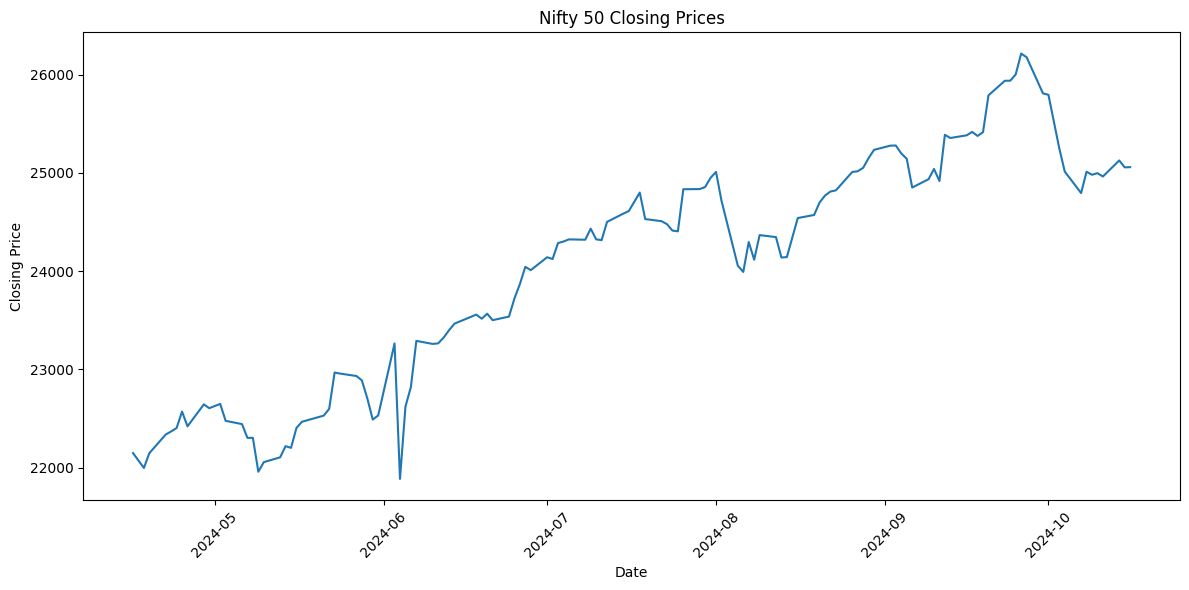

                       Date          Open          High           Low  \
0 2024-04-16 00:00:00+05:30  22125.300781  22213.750000  22079.449219   
1 2024-04-18 00:00:00+05:30  22212.349609  22326.500000  21961.699219   
2 2024-04-19 00:00:00+05:30  21861.500000  22179.550781  21777.650391   
3 2024-04-22 00:00:00+05:30  22336.900391  22375.650391  22198.150391   
4 2024-04-23 00:00:00+05:30  22447.050781  22447.550781  22349.449219   

          Close  Volume  Dividends  Stock Splits  
0  22147.900391  317300        0.0           0.0  
1  21995.849609  456900        0.0           0.0  
2  22147.000000  362500        0.0           0.0  
3  22336.400391  279300        0.0           0.0  
4  22368.000000  231500        0.0           0.0  


<Figure size 640x480 with 0 Axes>

In [2]:

import matplotlib.pyplot as plt

# Create a line plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'])
plt.title('Nifty 50 Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

plt.savefig('/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/nifty50_plot.png')

print(df.head())

Nifty 50 Moving Averages and Trading Signals

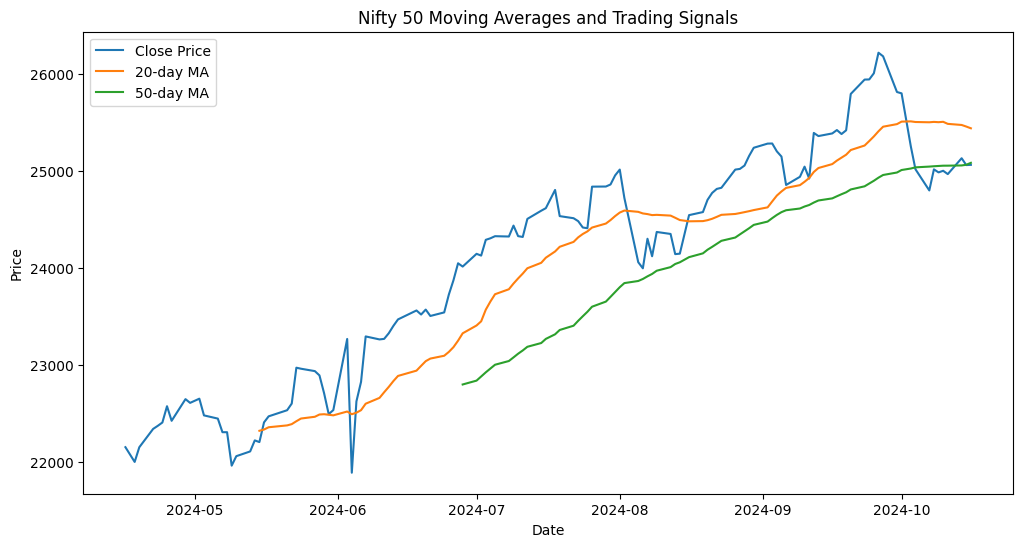

Number of buy signals: 76
Number of sell signals: 0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is already loaded with 6 months of data
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Generate trading signals
df['Signal'] = 0
df.loc[df['MA20'] > df['MA50'], 'Signal'] = 1
df.loc[df['MA20'] < df['MA50'], 'Signal'] = -1

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA20'], label='20-day MA')
plt.plot(df['Date'], df['MA50'], label='50-day MA')
plt.title('Nifty 50 Moving Averages and Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Print number of buy and sell signals
print("Number of buy signals:", (df['Signal'] == 1).sum())
print("Number of sell signals:", (df['Signal'] == -1).sum())

Nifty 50 Volatility Analysis

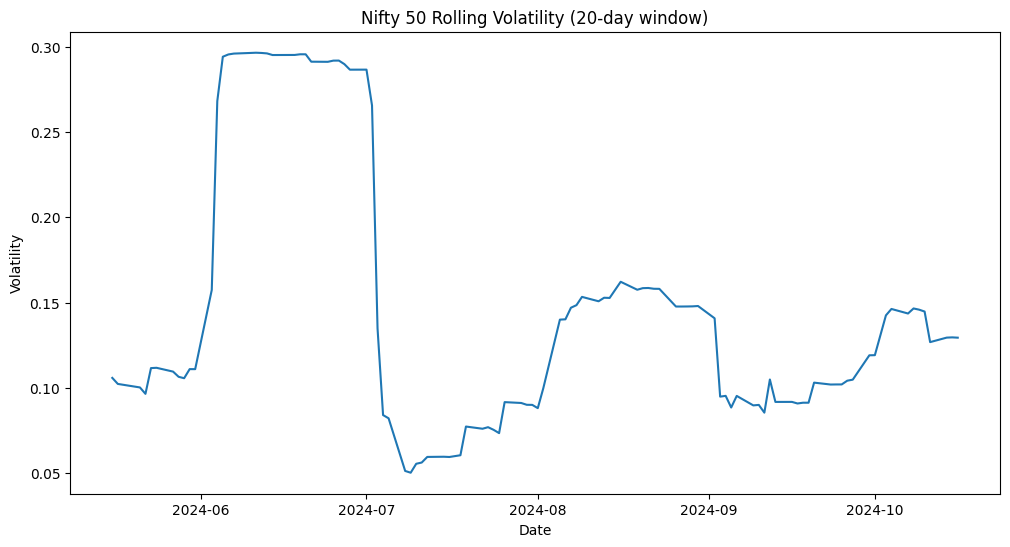

Average volatility over the period: 0.1456
Maximum volatility: 0.2964
Minimum volatility: 0.0503


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate daily returns
df['Returns'] = df['Close'].pct_change()

# Calculate rolling volatility (20-day window)
df['Volatility'] = df['Returns'].rolling(window=20).std() * np.sqrt(252)  # Annualized

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility'])
plt.title('Nifty 50 Rolling Volatility (20-day window)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

# Print average volatility
print(f"Average volatility over the period: {df['Volatility'].mean():.4f}")
print(f"Maximum volatility: {df['Volatility'].max():.4f}")
print(f"Minimum volatility: {df['Volatility'].min():.4f}")

Nifty 50 Trend Analysis using Linear Regression

In [7]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.5.2-cp39-cp39-macosx_10_9_x86_64.whl (12.1 MB)
  Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_10_9_x86_64.whl (39.4 MB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


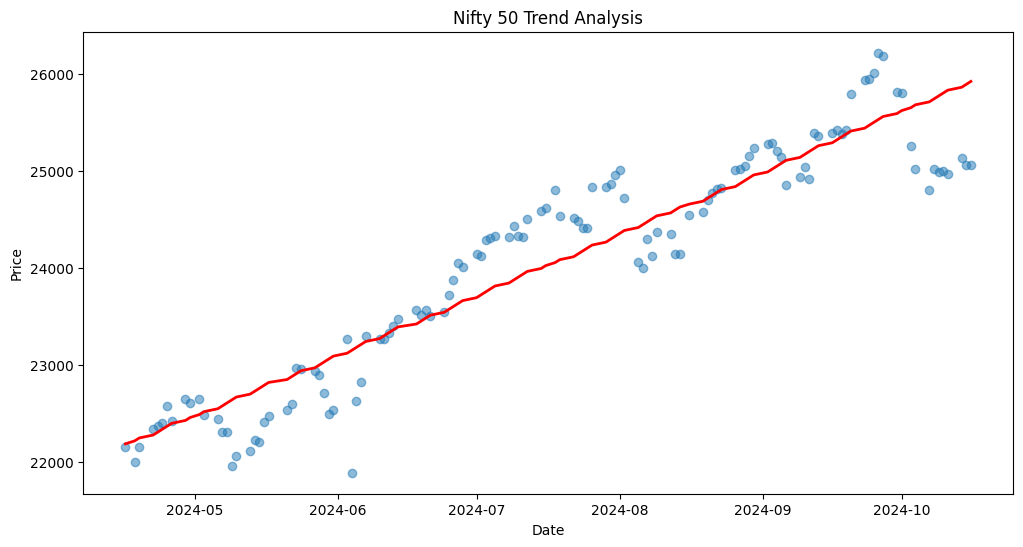

Trend slope: 30.1413
The overall trend is upward


In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Create a numeric index for regression
df['Index'] = range(len(df))

# Fit linear regression
model = LinearRegression()
model.fit(df[['Index']], df['Close'])

# Generate predictions
df['Trend'] = model.predict(df[['Index']])

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(df['Date'], df['Close'], alpha=0.5)
plt.plot(df['Date'], df['Trend'], color='red', linewidth=2)
plt.title('Nifty 50 Trend Analysis')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Calculate and print the slope
slope = model.coef_[0]
print(f"Trend slope: {slope:.4f}")
if slope > 0:
    print("The overall trend is upward")
else:
    print("The overall trend is downward")

Nifty 50 RSI Analysis

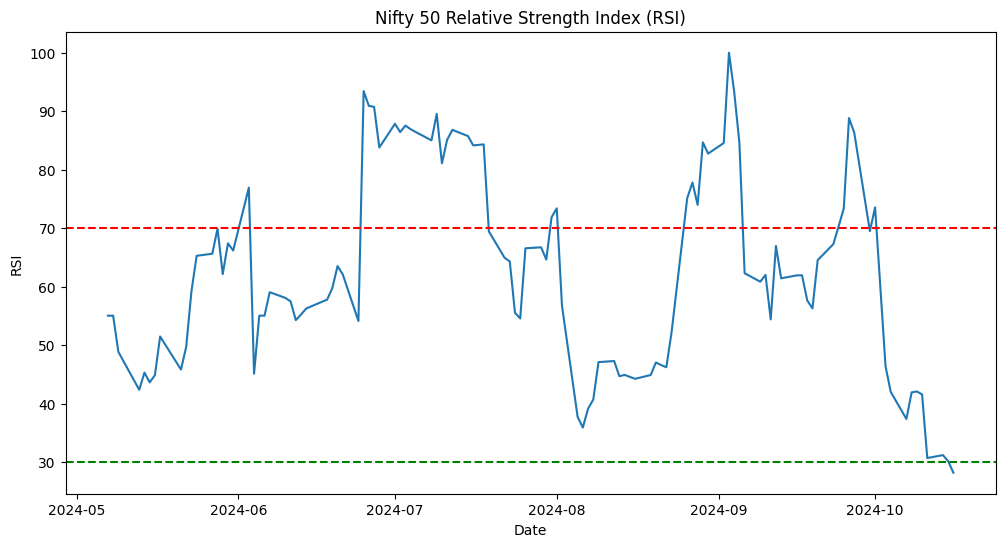

Number of overbought days: 34
Number of oversold days: 1


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_rsi(data, periods=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Calculate RSI
df['RSI'] = calculate_rsi(df['Close'])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['RSI'])
plt.title('Nifty 50 Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.axhline(y=70, color='r', linestyle='--')
plt.axhline(y=30, color='g', linestyle='--')
plt.show()

# Analyze overbought and oversold conditions
overbought = df[df['RSI'] > 70]
oversold = df[df['RSI'] < 30]

print(f"Number of overbought days: {len(overbought)}")
print(f"Number of oversold days: {len(oversold)}")

Nifty 50 Correlation Analysis with Global Indices



In [11]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 8.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


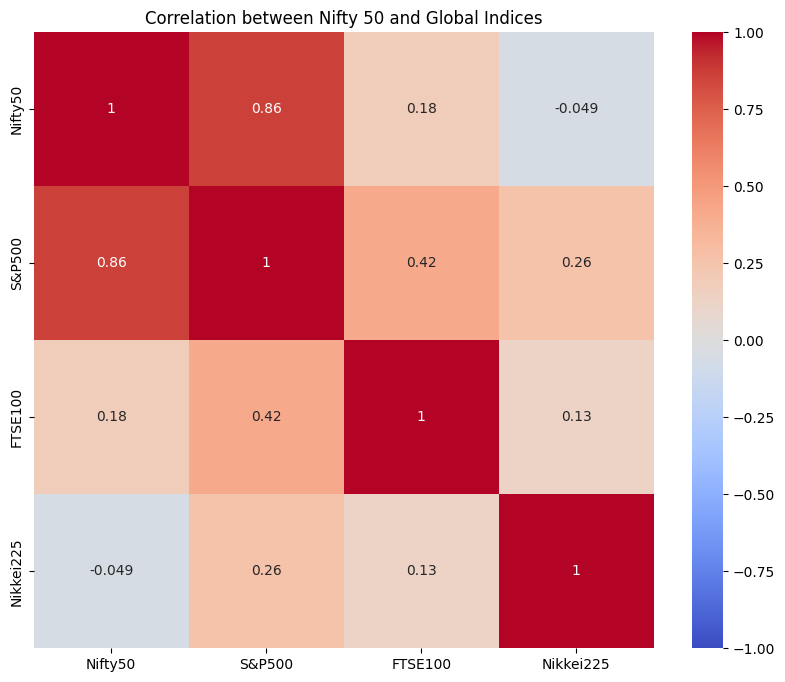

Correlation with Nifty 50:
Nifty50      1.000000
S&P500       0.860784
FTSE100      0.175799
Nikkei225   -0.048929
Name: Nifty50, dtype: float64


In [12]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fetch data for other indices
indices = {
    'Nifty50': '^NSEI',
    'S&P500': '^GSPC',
    'FTSE100': '^FTSE',
    'Nikkei225': '^N225'
}

data = {}
for name, ticker in indices.items():
    data[name] = yf.download(ticker, start=df['Date'].min(), end=df['Date'].max())['Close']

# Combine all data
combined_df = pd.DataFrame(data)

# Calculate correlation
correlation = combined_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation between Nifty 50 and Global Indices')
plt.show()

# Print correlation with Nifty 50
print("Correlation with Nifty 50:")
print(correlation['Nifty50'].sort_values(ascending=False))

Monte Carlo Simulation

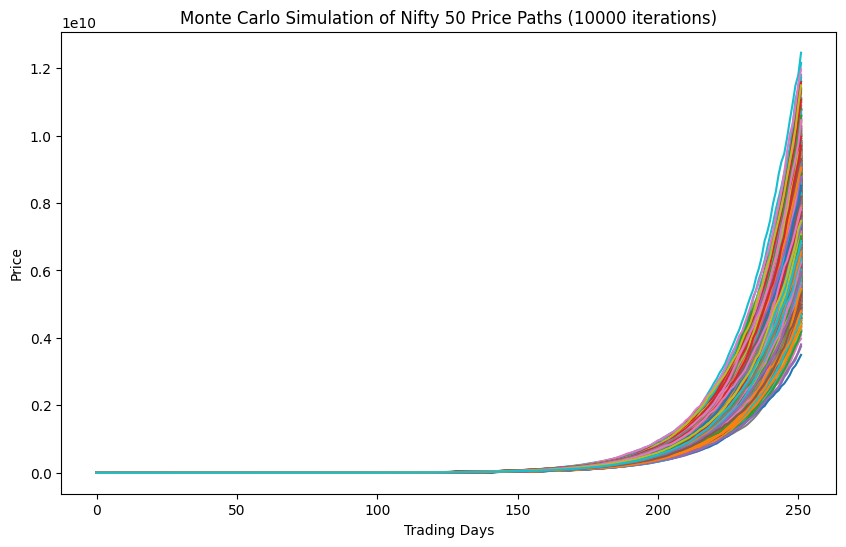

Predicted price after 252 trading days:
Mean: 7073353898.11
Max: 12458666718.02
Min: 3495703385.58
Standard Deviation: 1101816792.48

95% Confidence Interval:
Lower Bound: 4913832667.29
Upper Bound: 9232875128.92

99% Confidence Interval:
Lower Bound: 4235261916.90
Upper Bound: 9911445879.31


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming df is our DataFrame with Nifty 50 data

def monte_carlo_simulation(start_price, days, iterations, volatility, risk_free_rate):
    # Calculate daily returns
    daily_returns = np.exp(drift + volatility * norm.ppf(np.random.rand(days, iterations)))
    
    # Create price paths
    price_paths = np.zeros((days, iterations))
    price_paths[0] = start_price
    for t in range(1, days):
        price_paths[t] = price_paths[t-1] * daily_returns[t]
    
    return price_paths

# Calculate parameters
returns = df['Close'].pct_change().dropna()
days = 252  # Simulate for next 252 trading days (approximately 1 year)
iterations = 10000

volatility = returns.std()
risk_free_rate = 0.05  # Assume 5% risk-free rate, adjust as needed
S0 = df['Close'].iloc[-1]  # Last closing price

# Calculate drift
drift = risk_free_rate - 0.5 * volatility**2

# Run simulation
simulations = monte_carlo_simulation(S0, days, iterations, volatility, risk_free_rate)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(simulations)
plt.title(f'Monte Carlo Simulation of Nifty 50 Price Paths ({iterations} iterations)')
plt.xlabel('Trading Days')
plt.ylabel('Price')
plt.show()

# Calculate statistics
final_prices = simulations[-1, :]
mean_price = np.mean(final_prices)
max_price = np.max(final_prices)
min_price = np.min(final_prices)
std_dev = np.std(final_prices)

print(f"Predicted price after {days} trading days:")
print(f"Mean: {mean_price:.2f}")
print(f"Max: {max_price:.2f}")
print(f"Min: {min_price:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")

# Calculate confidence intervals
confidence_intervals = {
    '95%': norm.interval(0.95, loc=mean_price, scale=std_dev),
    '99%': norm.interval(0.99, loc=mean_price, scale=std_dev)
}

for ci, interval in confidence_intervals.items():
    print(f"\n{ci} Confidence Interval:")
    print(f"Lower Bound: {interval[0]:.2f}")
    print(f"Upper Bound: {interval[1]:.2f}")

Monte Carlo Simulation for Price Prediction

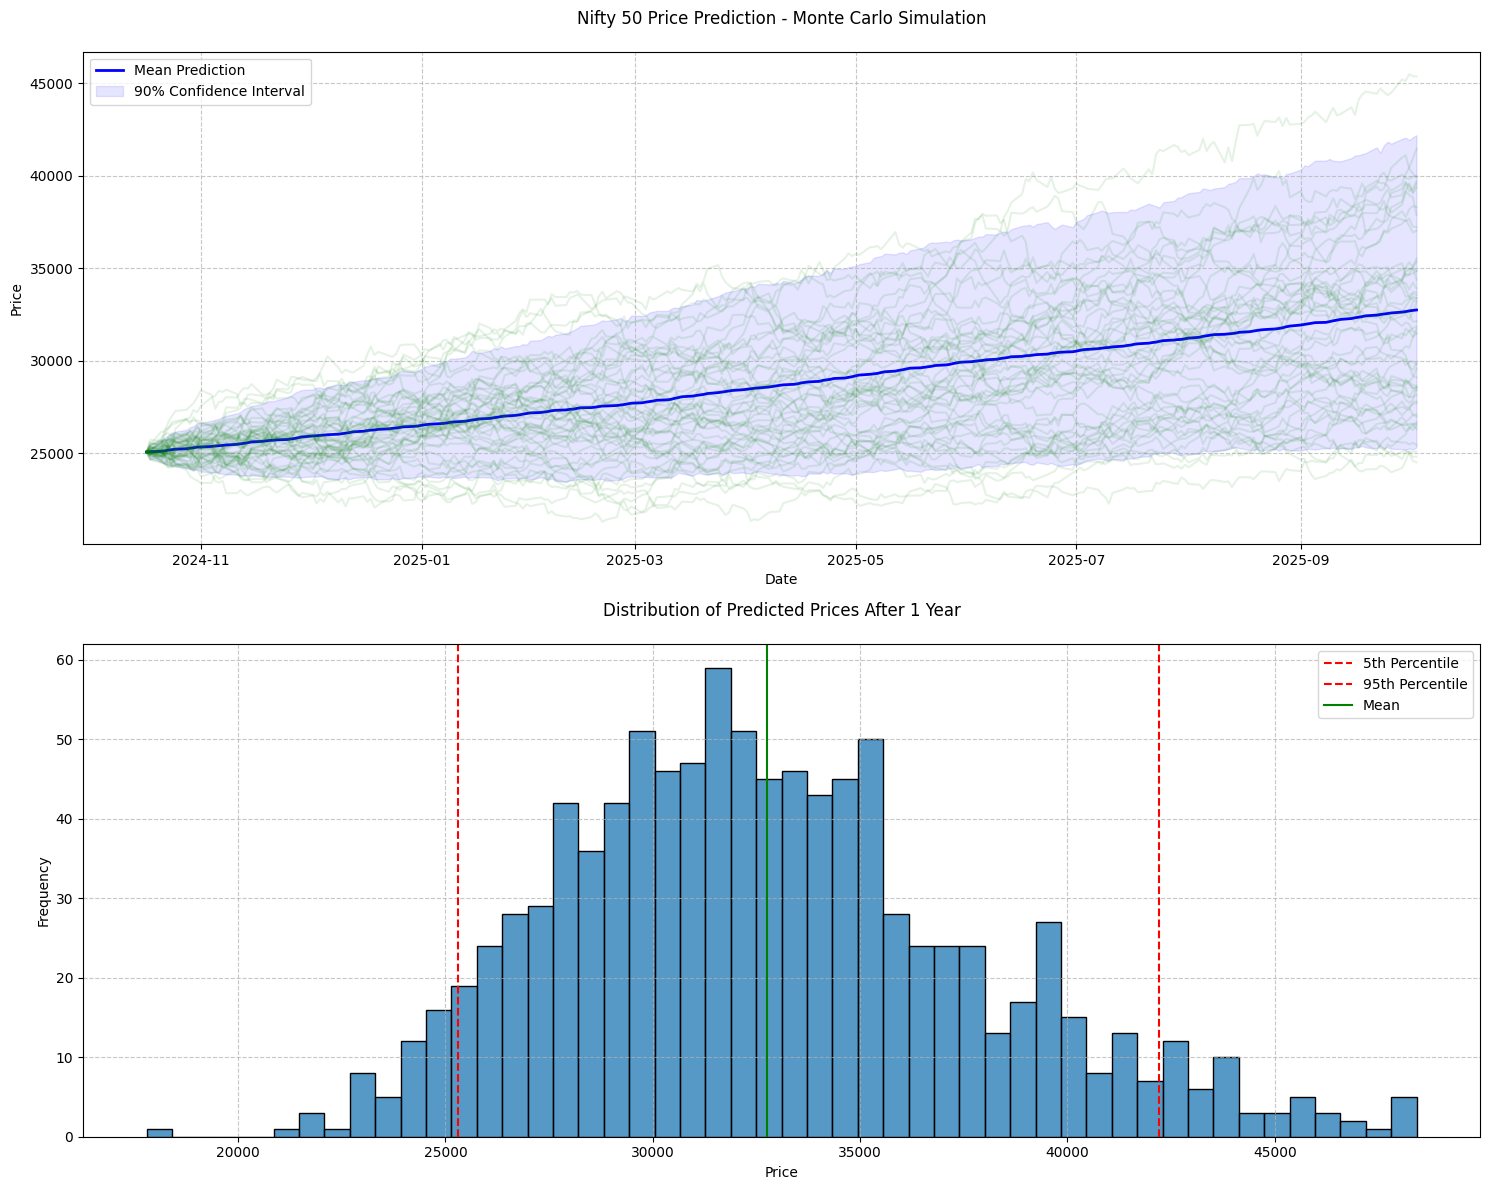


Monte Carlo Simulation Results

Initial Nifty 50 Price: ₹25,059.65

Predicted Price Statistics (After 1 Year):
Mean Price: ₹32,744.34
Median Price: ₹32,248.84
Standard Deviation: ₹5,050.80

Confidence Intervals:
90% CI: [₹25,307.42, ₹42,197.63]
95% CI: [₹24,418.85, ₹43,821.09]

Probability of Price Increase: 95.5%
Expected Annual Return: 30.7%

First few rows of predictions:
                       Date    Mean_Price      Upper_95       Lower_5
0 2024-10-17 00:00:00+05:30  25059.650391  25059.650391  25059.650391
1 2024-10-18 00:00:00+05:30  25077.572057  25473.670902  24689.184647
2 2024-10-21 00:00:00+05:30  25097.181952  25674.173161  24547.691466
3 2024-10-22 00:00:00+05:30  25120.452893  25825.927105  24427.437187
4 2024-10-23 00:00:00+05:30  25164.651975  25966.428364  24376.771283


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from datetime import datetime, timedelta

# Calculate daily returns and volatility
returns = np.log(1 + df['Close'].pct_change())
mu = returns.mean()
sigma = returns.std()

def predict_prices(S0, days, simulations):
    # Initialize price array
    prices = np.zeros((days, simulations))
    prices[0] = S0
    
    # Generate random walks
    for i in range(1, days):
        # Generate random numbers for simulation
        rand = np.random.standard_normal(simulations)
        # Calculate daily returns
        daily_returns = mu + sigma * rand
        # Calculate next day's price
        prices[i] = prices[i-1] * np.exp(daily_returns)
    
    return prices

# Set simulation parameters
S0 = df['Close'].iloc[-1]  # Last closing price
days = 252  # Trading days (1 year)
simulations = 1000

# Run simulation
predicted_prices = predict_prices(S0, days, simulations)

# Generate future dates for x-axis
if isinstance(df.index, pd.DatetimeIndex):
    last_date = df.index[-1]
else:
    # If the index is not datetime, convert the 'Date' column to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    last_date = df['Date'].iloc[-1]

# Create business days (excluding weekends)
future_dates = pd.date_range(start=last_date, periods=days+1, freq='B')[1:]

# Calculate statistics for each day
daily_stats = {
    'mean': np.mean(predicted_prices, axis=1),
    'std': np.std(predicted_prices, axis=1),
    'percentile_5': np.percentile(predicted_prices, 5, axis=1),
    'percentile_95': np.percentile(predicted_prices, 95, axis=1)
}

# Set the default matplotlib style
plt.style.use('default')

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Price Paths and Confidence Intervals
ax1.plot(future_dates, daily_stats['mean'], 'b-', label='Mean Prediction', linewidth=2)
ax1.fill_between(future_dates, 
                 daily_stats['percentile_5'], 
                 daily_stats['percentile_95'], 
                 color='blue', alpha=0.1, 
                 label='90% Confidence Interval')

# Plot only a subset of paths for better visualization
for i in range(50):  # Plot 50 sample paths
    ax1.plot(future_dates, predicted_prices[:, i], 'g-', alpha=0.1)

ax1.set_title('Nifty 50 Price Prediction - Monte Carlo Simulation', fontsize=12, pad=20)
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Price', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot 2: Final Price Distribution
final_prices = predicted_prices[-1, :]
sns.histplot(data=final_prices, bins=50, ax=ax2)
ax2.axvline(np.percentile(final_prices, 5), color='r', linestyle='--', 
            label='5th Percentile')
ax2.axvline(np.percentile(final_prices, 95), color='r', linestyle='--', 
            label='95th Percentile')
ax2.axvline(np.mean(final_prices), color='g', linestyle='-', 
            label='Mean')
ax2.set_title('Distribution of Predicted Prices After 1 Year', fontsize=12, pad=20)
ax2.set_xlabel('Price', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

# Print analysis results
print("\nMonte Carlo Simulation Results")
print("=" * 40)
print(f"\nInitial Nifty 50 Price: ₹{S0:,.2f}")
print("\nPredicted Price Statistics (After 1 Year):")
print(f"Mean Price: ₹{np.mean(final_prices):,.2f}")
print(f"Median Price: ₹{np.median(final_prices):,.2f}")
print(f"Standard Deviation: ₹{np.std(final_prices):,.2f}")

print("\nConfidence Intervals:")
print(f"90% CI: [₹{np.percentile(final_prices, 5):,.2f}, ₹{np.percentile(final_prices, 95):,.2f}]")
print(f"95% CI: [₹{np.percentile(final_prices, 2.5):,.2f}, ₹{np.percentile(final_prices, 97.5):,.2f}]")

# Calculate probability of price increase
prob_increase = np.mean(final_prices > S0) * 100
print(f"\nProbability of Price Increase: {prob_increase:.1f}%")

# Calculate returns
expected_return = ((np.mean(final_prices) - S0) / S0) * 100
print(f"Expected Annual Return: {expected_return:.1f}%")

# Save predictions to DataFrame
prediction_df = pd.DataFrame({
    'Date': future_dates,
    'Mean_Price': daily_stats['mean'],
    'Upper_95': daily_stats['percentile_95'],
    'Lower_5': daily_stats['percentile_5']
})

# Display first few rows of predictions
print("\nFirst few rows of predictions:")
print(prediction_df.head().to_string())